In [5]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
# ============================================================
# 2. CARGAR DATASET DE AGRUPACIÓN
# ============================================================

df_cluster = pd.read_csv("https://raw.githubusercontent.com/BAcost26/Datos-python/refs/heads/main/Parcial4/clave_A_agrupacion.csv")

print("Primeras filas del dataset:")
display(df_cluster.head())

print("Cantidad de filas y columnas:")
print(df_cluster.shape)

print("Tipos de datos:")
print(df_cluster.dtypes)

Primeras filas del dataset:


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,A-R0009,18,447,0.55,21.04,5.46,2,7
1,A-R0023,22,624,3.82,33.36,7.31,2,1
2,A-R0099,34,1091,8.12,105.43,7.51,1,21
3,A-R0159,46,1365,10.62,158.81,7.74,12,43
4,A-R0221,52,570,3.82,32.46,4.63,5,15


Cantidad de filas y columnas:
(230, 8)
Tipos de datos:
registro_id          object
edad                  int64
ingresos              int64
frecuencia_uso      float64
gasto_promedio      float64
satisfaccion        float64
reclamos              int64
antiguedad_meses      int64
dtype: object


In [7]:
# ============================================================
# 3. REVISAR VALORES NULOS
# ============================================================

print("Valores nulos:")
print(df_cluster.isnull().sum())

# Rellenar valores nulos numéricos con la mediana
columnas_numericas_cluster = df_cluster.select_dtypes(include=["int64", "float64"]).columns

for col in columnas_numericas_cluster:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

print("\nValores nulos después de limpieza:")
print(df_cluster.isnull().sum())

Valores nulos:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

Valores nulos después de limpieza:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


In [8]:
# ============================================================
# 4. SELECCIONAR VARIABLES PARA CLUSTERING
# ============================================================

variables_cluster = [
    "edad",
    "ingresos",
    "frecuencia_uso",
    "gasto_promedio",
    "satisfaccion",
    "reclamos",
    "antiguedad_meses"
]

X = df_cluster[variables_cluster]

print("Variables seleccionadas para clustering:")
print(variables_cluster)

print("\nJustificación:")
print("Se seleccionaron estas variables porque permiten representar el perfil del cliente,")
print("su comportamiento de uso, nivel de gasto, satisfacción, reclamos y antigüedad.")

Variables seleccionadas para clustering:
['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']

Justificación:
Se seleccionaron estas variables porque permiten representar el perfil del cliente,
su comportamiento de uso, nivel de gasto, satisfacción, reclamos y antigüedad.


In [9]:
# ============================================================
# 5. NORMALIZAR LOS DATOS
# ============================================================

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("Datos normalizados correctamente.")

Datos normalizados correctamente.


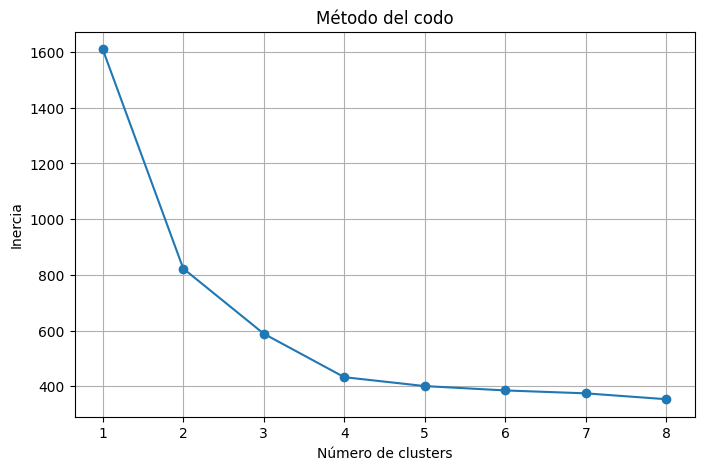

In [10]:
# ============================================================
# 6. MÉTODO DEL CODO PARA ELEGIR NÚMERO DE CLUSTERS
# ============================================================

inercias = []

rango_k = range(1, 9)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_escalado)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [11]:
# ============================================================
# 7. EVALUAR SILHOUETTE PARA APOYAR LA DECISIÓN
# ============================================================

print("Puntaje silhouette por cantidad de clusters:")

for k in range(2, 9):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_escalado)
    score = silhouette_score(X_escalado, etiquetas)
    print(f"K={k}: {score:.3f}")

Puntaje silhouette por cantidad de clusters:
K=2: 0.415
K=3: 0.369
K=4: 0.400
K=5: 0.404
K=6: 0.333
K=7: 0.258
K=8: 0.222


In [12]:
# ============================================================
# 8. APLICAR K-MEANS
# ============================================================

# Para este caso se utilizarán 3 clusters
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

df_cluster["cluster"] = kmeans.fit_predict(X_escalado)

print("Dataset con columna de cluster:")
display(df_cluster.head())

Dataset con columna de cluster:


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,A-R0009,18,447,0.55,21.04,5.46,2,7,1
1,A-R0023,22,624,3.82,33.36,7.31,2,1,1
2,A-R0099,34,1091,8.12,105.43,7.51,1,21,0
3,A-R0159,46,1365,10.62,158.81,7.74,12,43,2
4,A-R0221,52,570,3.82,32.46,4.63,5,15,1


In [13]:
# ============================================================
# 9. RESUMEN DE CADA CLUSTER
# ============================================================

resumen_clusters = df_cluster.groupby("cluster")[variables_cluster].mean()

print("Promedio de variables por cluster:")
display(resumen_clusters)

print("Cantidad de clientes por cluster:")
display(df_cluster["cluster"].value_counts())

Promedio de variables por cluster:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,31.615385,941.815385,6.524308,78.947692,8.258462,1.184615,18.153846
1,29.181818,657.663636,3.054182,44.000909,5.315364,4.009091,8.581818
2,45.563636,1489.818182,9.120727,134.649818,8.502000,0.909091,35.963636


Cantidad de clientes por cluster:


,count
cluster,
1,110
0,65
2,55


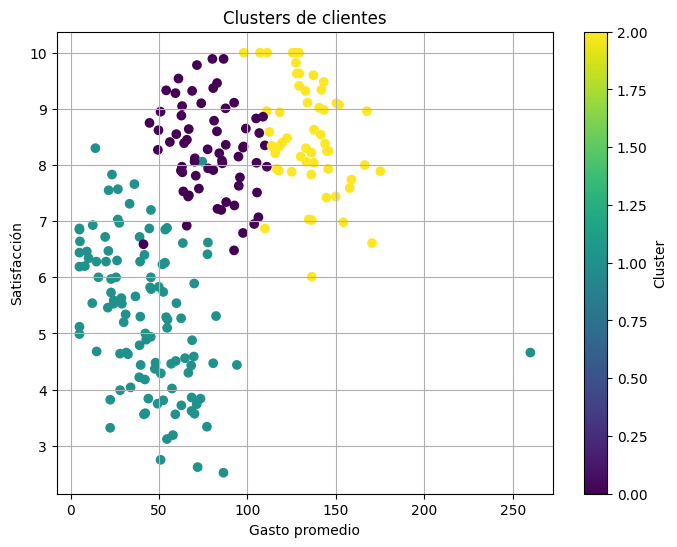

In [14]:
# ============================================================
# 10. VISUALIZAR LOS CLUSTERS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df_cluster["gasto_promedio"],
    df_cluster["satisfaccion"],
    c=df_cluster["cluster"],
    cmap="viridis"
)

plt.title("Clusters de clientes")
plt.xlabel("Gasto promedio")
plt.ylabel("Satisfacción")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [15]:
# ============================================================
# 11. INTERPRETACIÓN AUTOMÁTICA DE CLUSTERS
# ============================================================

for cluster in sorted(df_cluster["cluster"].unique()):
    datos = df_cluster[df_cluster["cluster"] == cluster]

    print(f"CLUSTER {cluster}")
    print(f"Cantidad de clientes: {len(datos)}")
    print(f"Edad promedio: {datos['edad'].mean():.2f}")
    print(f"Ingresos promedio: {datos['ingresos'].mean():.2f}")
    print(f"Frecuencia de uso promedio: {datos['frecuencia_uso'].mean():.2f}")
    print(f"Gasto promedio: {datos['gasto_promedio'].mean():.2f}")
    print(f"Satisfacción promedio: {datos['satisfaccion'].mean():.2f}")
    print(f"Reclamos promedio: {datos['reclamos'].mean():.2f}")
    print(f"Antigüedad promedio en meses: {datos['antiguedad_meses'].mean():.2f}")
    print("-" * 80)

CLUSTER 0
Cantidad de clientes: 65
Edad promedio: 31.62
Ingresos promedio: 941.82
Frecuencia de uso promedio: 6.52
Gasto promedio: 78.95
Satisfacción promedio: 8.26
Reclamos promedio: 1.18
Antigüedad promedio en meses: 18.15
--------------------------------------------------------------------------------
CLUSTER 1
Cantidad de clientes: 110
Edad promedio: 29.18
Ingresos promedio: 657.66
Frecuencia de uso promedio: 3.05
Gasto promedio: 44.00
Satisfacción promedio: 5.32
Reclamos promedio: 4.01
Antigüedad promedio en meses: 8.58
--------------------------------------------------------------------------------
CLUSTER 2
Cantidad de clientes: 55
Edad promedio: 45.56
Ingresos promedio: 1489.82
Frecuencia de uso promedio: 9.12
Gasto promedio: 134.65
Satisfacción promedio: 8.50
Reclamos promedio: 0.91
Antigüedad promedio en meses: 35.96
--------------------------------------------------------------------------------


In [16]:
# ============================================================
# 12. ACCIONES DE NEGOCIO POR CLUSTER
# ============================================================

print("ACCIONES DE NEGOCIO PROPUESTAS:")

print("""
Cluster 0:
Se recomienda analizar sus características promedio. Si presenta buen gasto y satisfacción,
puede trabajarse con programas de fidelización, descuentos exclusivos o beneficios especiales.

Cluster 1:
Si presenta bajo uso o bajo gasto promedio, se pueden aplicar campañas de reactivación,
promociones personalizadas o incentivos para aumentar la frecuencia de compra.

Cluster 2:
Si presenta más reclamos o menor satisfacción, se recomienda mejorar la atención al cliente,
dar seguimiento personalizado y aplicar estrategias para reducir inconformidades.
""")

ACCIONES DE NEGOCIO PROPUESTAS:

Cluster 0:
Se recomienda analizar sus características promedio. Si presenta buen gasto y satisfacción,
puede trabajarse con programas de fidelización, descuentos exclusivos o beneficios especiales.

Cluster 1:
Si presenta bajo uso o bajo gasto promedio, se pueden aplicar campañas de reactivación,
promociones personalizadas o incentivos para aumentar la frecuencia de compra.

Cluster 2:
Si presenta más reclamos o menor satisfacción, se recomienda mejorar la atención al cliente,
dar seguimiento personalizado y aplicar estrategias para reducir inconformidades.



In [17]:
# ============================================================
# 13. EXPORTAR DATASET FINAL CON CLUSTER
# ============================================================

df_cluster.to_csv("clave_A_agrupacion_con_clusters.csv", index=False)

print("Archivo generado correctamente: clave_A_agrupacion_con_clusters.csv")

Archivo generado correctamente: clave_A_agrupacion_con_clusters.csv
